In [ ]:
!pip install imodels
!pip install sklearn

Data types of columns:
Domain           object
Have_IP           int64
Have_At           int64
URL_Length        int64
URL_Depth         int64
Redirection       int64
https_Domain      int64
TinyURL           int64
Prefix/Suffix     int64
DNS_Record        int64
Web_Traffic       int64
Domain_Age        int64
Domain_End        int64
iFrame            int64
Mouse_Over        int64
Right_Click       int64
Web_Forwards      int64
Label             int64
dtype: object
Before SMOTE: Class distribution in y_train: 1    4012
0    3988
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 1    4012
0    4012
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by Random Forest: Index(['Domain', 'URL_Length', 'URL_Depth', 'Prefix/Suffix'], dtype='object')
Random Forest Accuracy (Selected Features): 0.959
Random Forest ROC-AUC (Selected Features): 0.9871491494775247
Random Forest Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1012
           1       0.98      0.94      0.96       988

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



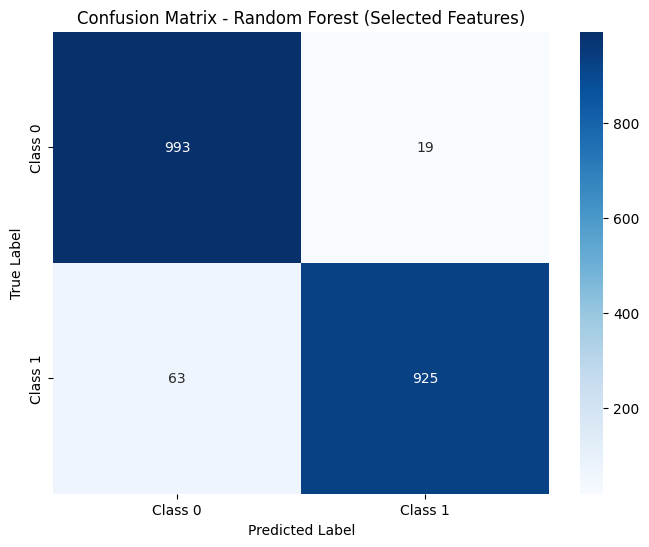

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.14794318286431007, tolerance: 0.13362673396896593
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.35347916410330527, tolerance: 0.13362673396896593
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.27148206627441596, tolerance: 0.13362673396896593
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\DELL\AppData\Roamin

Top 10 Rules from RuleFit Model:
                                                   rule  type      coef  \
940   URL_Depth <= 9.0 & Domain > 1985.0 & URL_Lengt...  rule  0.377015   
241   Domain > 2290.5 & URL_Depth <= 7.5 & Domain > ...  rule -0.377005   
754   Domain <= 2960.0 & Domain <= 3521.5 & Domain <...  rule  0.426692   
763                 Domain <= 3068.0 & Domain <= 2894.5  rule -0.413656   
70    Domain <= 3298.0 & Domain <= 3370.5 & URL_Dept...  rule  0.316219   
40    Domain <= 3208.5 & Domain > 2002.5 & Domain > ...  rule -0.380029   
167   Prefix/Suffix <= 0.5 & Domain <= 3381.0 & URL_...  rule -0.292544   
1017  Domain > 1186.5 & Domain > 1273.5 & Domain > 33.5  rule -0.284874   
258   Domain <= 2001.0 & Domain <= 1772.0 & URL_Dept...  rule -0.255218   
990                   Domain > 2463.0 & Domain > 2475.0  rule -0.265140   

       support  importance  
940   0.350078    0.179834  
241   0.334380    0.177861  
754   0.180534    0.164119  
763   0.810047    0.16226

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.706e+01, tolerance: 2.006e-01
  model = cd_fast.enet_coordinate_descent(


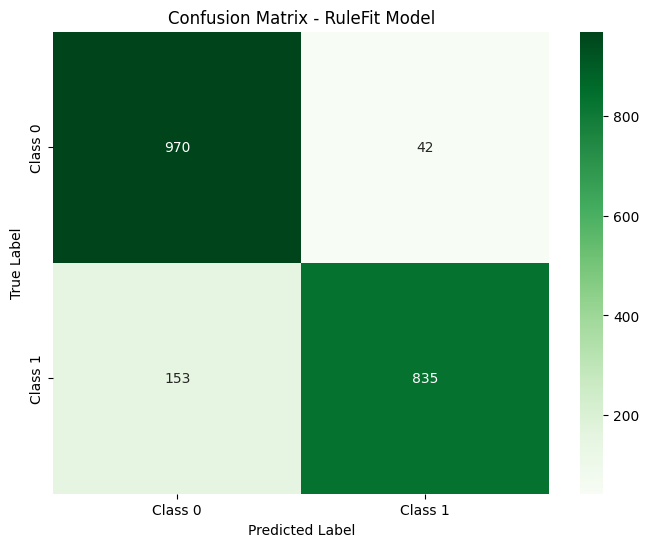

In [26]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
#from imodels 
#import RuleFit
from rulefit import RuleFit
import matplotlib.pyplot as plt
import seaborn as sns

# Set the LOKY_MAX_CPU_COUNT environment variable to bypass CPU count issues
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Adjust based on the number of cores you want to use

# Step 1: Load dataset
df = pd.read_csv('ds_10K18.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using Random Forest
# Train an initial Random Forest model to get feature importances
rf_initial_model = RandomForestClassifier(random_state=42)
rf_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on Random Forest feature importances
feature_selector = SelectFromModel(rf_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by Random Forest: {selected_features}")

# Step 6: Train final Random Forest model with selected features (Optional step for comparison)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train_resampled)

# Predict and evaluate the Random Forest model (Optional step for comparison)
y_pred = rf_model.predict(X_test_selected)
y_proba = rf_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)

print(f"Random Forest Accuracy (Selected Features): {rf_accuracy}")
print(f"Random Forest ROC-AUC (Selected Features): {rf_roc_auc}")
print("Random Forest Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 7: Confusion matrix visualization for Random Forest model
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Random Forest (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 8: Train RuleFit Model for Explainability
# RuleFit model does not require discretization or one-hot encoding
rulefit_model = RuleFit(random_state=42)
rulefit_model.fit(X_train_selected, y_train_resampled, feature_names=selected_features)

# Step 9: Get rules and feature importances from the RuleFit model
rules_df = rulefit_model.get_rules()
rules_df = rules_df[rules_df.coef != 0].sort_values("importance", ascending=False)  # Filter non-zero rules

# Print top 10 rules
print("Top 10 Rules from RuleFit Model:")
print(rules_df.head(10))

# Step 10: Predict and Evaluate RuleFit Model
# Predict using RuleFit model (continuous output)
y_pred_rulefit_continuous = rulefit_model.predict(X_test_selected)

# Convert continuous predictions to binary predictions
# Use a threshold of 0.5 (can be adjusted as needed)
y_pred_rulefit = np.where(y_pred_rulefit_continuous >= 0.5, 1, 0)

# Evaluate RuleFit Model
rulefit_accuracy = accuracy_score(y_test, y_pred_rulefit)
rulefit_roc_auc = roc_auc_score(y_test, y_pred_rulefit)  # If y_pred_rulefit_continuous is used, you can evaluate ROC-AUC directly.

print(f"RuleFit Model Accuracy: {rulefit_accuracy}")
print(f"RuleFit Model ROC-AUC: {rulefit_roc_auc}")

# Confusion matrix for RuleFit model
conf_matrix_rulefit = confusion_matrix(y_test, y_pred_rulefit)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rulefit, annot=True, fmt='d', cmap='Greens', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - RuleFit Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
